a very important dimension to your patent intelligence system:

Instead of only asking:

"What technologies exist?"

you can answer:

"Which patents influenced the field and how did innovation evolve?"

Your pipeline becomes:

Patent Dataset
      |
      |
Citation Relationships
      |
      ↓
Graph Network
      |
      ↓
Centrality Algorithms
      |
      ↓
Influential Patent Discovery

Citation Network Analysis

Build patent citation networks.

Metrics:

* Most influential patents.
* Central patents.
* Technology evolution paths.

Algorithms:

* PageRank
* Degree Centrality
* Betweenness Centrality

In [1]:
import pandas as pd

# create a new dataset for embeddings.
DATA_PATH = "../data/processed/cleaned_patent_data.csv"


df = pd.read_csv(DATA_PATH)


print(df.columns)

Index(['source_url', 'patent_id', 'title', 'title_en', 'abstract',
       'abstract_en', 'description', 'claims', 'filing_date',
       'publication_date', 'country', 'assignee_original', 'assignee_en',
       'ipc_codes', 'cpc_codes', 'claim_count', 'independent_claim_count',
       'backward_citation_count', 'forward_citation_count', 'legal_status',
       'detected_language', 'claims_clean', 'combined_text', 'abstract_length',
       'word_count', 'claims_length_chars', 'claims_word_count',
       'claims_length', 'filing_year', 'year'],
      dtype='object')


In [2]:
df[
[
"patent_id",
"forward_citation_count",
"backward_citation_count"
]
].head()

,patent_id,forward_citation_count,backward_citation_count
0,CN102708128A,0,60
1,KR102798691B1,0,62
2,US11913937B2,0,81
3,JP7095207B2,0,75
4,CN108538402A,0,57


In [3]:
df["forward_citation_count"].value_counts()

forward_citation_count
0      18313
4          6
2          6
7          4
3          4
10         3
5          2
6          2
12         2
8          2
1          1
146        1
35         1
21         1
20         1
13         1
16         1
135        1
Name: count, dtype: int64

In [4]:
positive_forward = (
    df["forward_citation_count"] > 0
).sum()

print(
    "Patents with forward citations:",
    positive_forward
)

Patents with forward citations: 39


In [5]:
df["backward_citation_count"].value_counts()

backward_citation_count
42      774
41      756
40      741
37      741
39      740
       ... 
2062      1
2061      1
471       1
298       1
360       1
Name: count, Length: 390, dtype: int64

Backward Citation Count
Meaning:

Backward citations = Number of older patents that this patent refers to

It represents:

"Which previous inventions did this patent build upon?"

Forward Citation Count
Meaning:

Forward citations = Number of newer patents that cite this patent

It represents:

"How many future inventions considered this patent important?"


In [6]:
# import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

In [7]:
citation_cols = [
    "patent_id",
    "forward_citation_count",
    "backward_citation_count"
]


df[citation_cols].head()

,patent_id,forward_citation_count,backward_citation_count
0,CN102708128A,0,60
1,KR102798691B1,0,62
2,US11913937B2,0,81
3,JP7095207B2,0,75
4,CN108538402A,0,57


In [8]:
df[citation_cols].isnull().sum()

patent_id                  0
forward_citation_count     0
backward_citation_count    0
dtype: int64

### Step 4: Citation Statistics

In [9]:
# Forward citation distribution
df["forward_citation_count"].describe()

count    18352.000000
mean         0.030242
std          1.534416
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        146.000000
Name: forward_citation_count, dtype: float64

In [10]:
# backward citation distribution
df["backward_citation_count"].describe()

count    18352.000000
mean        49.763677
std         70.552681
min          0.000000
25%         33.000000
50%         40.000000
75%         47.000000
max       2062.000000
Name: backward_citation_count, dtype: float64

#### Count patents with citations

In [11]:
print(
    "Forward cited patents:",
    (df["forward_citation_count"]>0).sum()
)


print(
    "Backward cited patents:",
    (df["backward_citation_count"]>0).sum()
)

Forward cited patents: 39
Backward cited patents: 18268


## Visualize Citation Distribution
#### Backward citation histogram

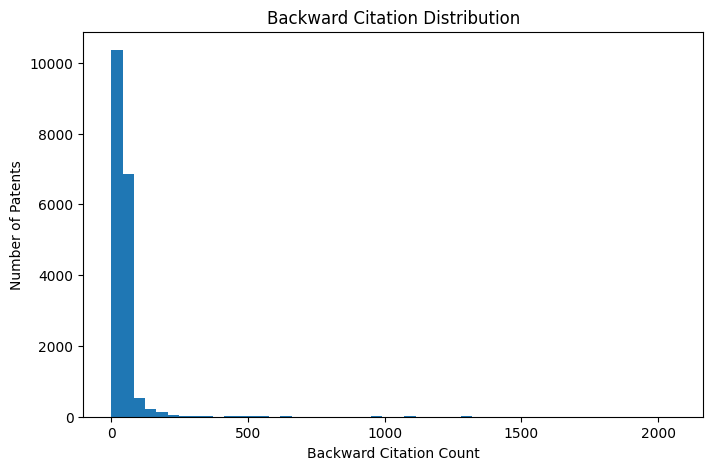

In [12]:
plt.figure(figsize=(8,5))


plt.hist(
    df["backward_citation_count"],
    bins=50
)


plt.xlabel(
    "Backward Citation Count"
)

plt.ylabel(
    "Number of Patents"
)


plt.title(
    "Backward Citation Distribution"
)


plt.show()

#### Forward citation histogram

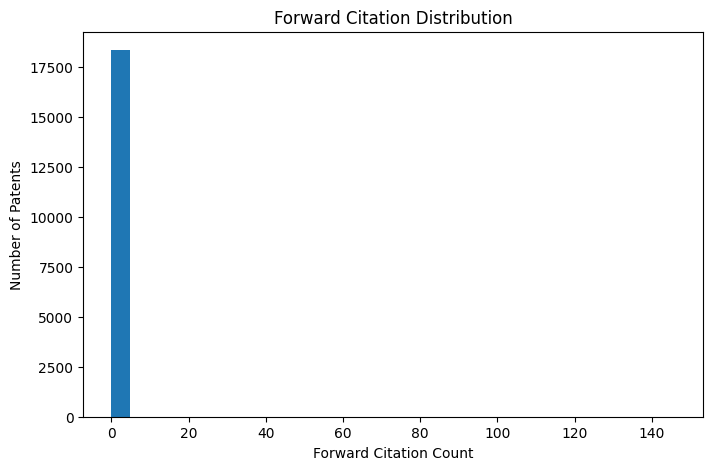

In [13]:
plt.figure(figsize=(8,5))


plt.hist(
    df["forward_citation_count"],
    bins=30
)


plt.xlabel(
    "Forward Citation Count"
)

plt.ylabel(
    "Number of Patents"
)


plt.title(
    "Forward Citation Distribution"
)


plt.show()

## Create Patent Age Feature

#### Older patents have more time to accumulate citations.

In [14]:
CURRENT_YEAR = 2026


df["patent_age"] = (
    CURRENT_YEAR
    -
    df["filing_year"]
)


df[
[
"patent_id",
"filing_year",
"patent_age"
]
].head()

,patent_id,filing_year,patent_age
0,CN102708128A,2012.0,14.0
1,KR102798691B1,2021.0,5.0
2,US11913937B2,2021.0,5.0
3,JP7095207B2,2019.0,7.0
4,CN108538402A,2018.0,8.0


In [15]:
#Step 7: Normalize Citation Features
#Problem:
#Different scales:
#Normalize them:

scaler = MinMaxScaler()


df[
[
"forward_norm",
"backward_norm",
"age_norm"
]
] = scaler.fit_transform(
df[
[
"forward_citation_count",
"backward_citation_count",
"patent_age"
]
]
)

In [16]:
#Check:
df[
[
"forward_norm",
"backward_norm",
"age_norm"
]
].head()

,forward_norm,backward_norm,age_norm
0,0.0,0.029098,0.424242
1,0.0,0.030068,0.151515
2,0.0,0.039282,0.151515
3,0.0,0.036372,0.212121
4,0.0,0.027643,0.242424


In [17]:
#Step 8: Create Citation Influence Score
#For patent intelligence:
#Weight:

df["citation_influence_score"] = (

    0.5 * df["forward_norm"]

    +

    0.3 * df["backward_norm"]

    +

    0.2 * df["age_norm"]

)

In [18]:
#Create a new CSV
#Don't overwrite your original cleaned dataset. Save a new version.
OUTPUT_PATH = "../data/processed/cleaned_patent_data_with_citations.csv"

df.to_csv(
    OUTPUT_PATH,
    index=False
)

print(f"Saved to: {OUTPUT_PATH}")

Saved to: ../data/processed/cleaned_patent_data_with_citations.csv


In [19]:
#Verify
import pandas as pd

df_check = pd.read_csv(
    "../data/processed/cleaned_patent_data_with_citations.csv"
)

print(df_check.columns)

Index(['source_url', 'patent_id', 'title', 'title_en', 'abstract',
       'abstract_en', 'description', 'claims', 'filing_date',
       'publication_date', 'country', 'assignee_original', 'assignee_en',
       'ipc_codes', 'cpc_codes', 'claim_count', 'independent_claim_count',
       'backward_citation_count', 'forward_citation_count', 'legal_status',
       'detected_language', 'claims_clean', 'combined_text', 'abstract_length',
       'word_count', 'claims_length_chars', 'claims_word_count',
       'claims_length', 'filing_year', 'year', 'patent_age', 'forward_norm',
       'backward_norm', 'age_norm', 'citation_influence_score'],
      dtype='object')


In [20]:
#Check:
df[
[
"patent_id",
"citation_influence_score"
]
].head()

,patent_id,citation_influence_score
0,CN102708128A,0.093578
1,KR102798691B1,0.039323
2,US11913937B2,0.042088
3,JP7095207B2,0.053336
4,CN108538402A,0.056778


In [21]:
#Step 9: Rank Influential Patents
#Top 20:
top_patents = (
    df.sort_values(
        "citation_influence_score",
        ascending=False
    )
    .head(20)
)


top_patents[
[
"patent_id",
"title",
"forward_citation_count",
"backward_citation_count",
"citation_influence_score"
]
]

,patent_id,title,forward_citation_count,backward_citation_count,citation_influence_score
17064,MX2007008055A,Hand washing compliance system.,135,0,0.577480
16230,MX2017009326A,SYSTEM AND PROCEDURE FOR DATA EXCHANGE IN HEAL...,146,0,0.560606
11236,EP4013297A1,Device and method for medical diagnostics,0,2062,0.336364
11237,WO2021034784A1,Device and method for medical diagnostics,0,2061,0.336218
17828,CN101878002A,Customized patient-specific orthopaedic surgic...,0,1528,0.331399
15351,US7624028B1,Remote health monitoring and maintenance system,0,1077,0.320329
17160,US5550734A,Computerized healthcare accounts receivable pu...,0,658,0.295732
17646,US6804558B2,System and method of communicating between an ...,0,931,0.286966
16723,US5471382A,Medical network management system and process,0,533,0.271485
11187,US20110082711A1,Personal digital assistant or organizer for mo...,0,1181,0.268793


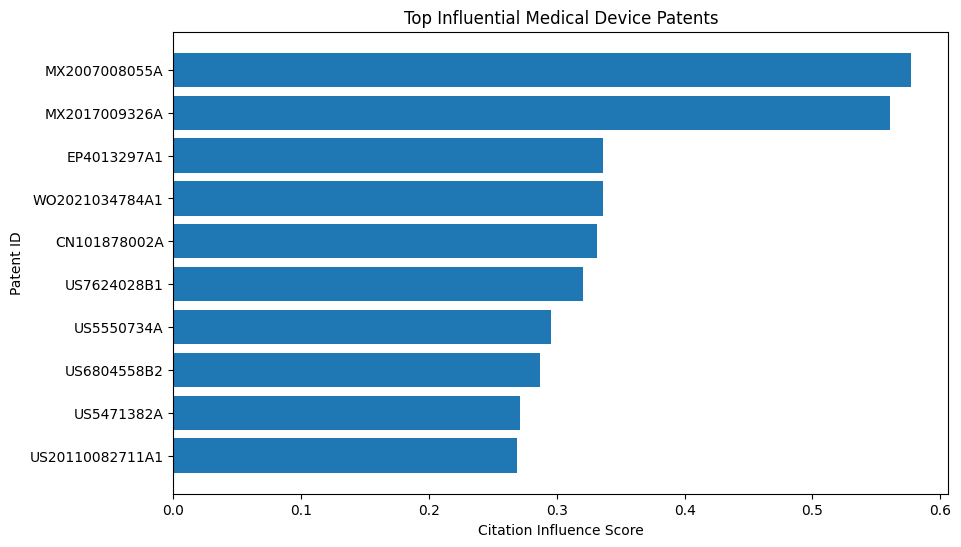

In [22]:
#Step 10: Visualization
#Top 10 influential patents

top10 = top_patents.head(10)


plt.figure(figsize=(10,6))


plt.barh(
    top10["patent_id"],
    top10["citation_influence_score"]
)


plt.xlabel(
    "Citation Influence Score"
)


plt.ylabel(
    "Patent ID"
)


plt.title(
    "Top Influential Medical Device Patents"
)


plt.gca().invert_yaxis()


plt.show()

In [23]:
#Merge the two datasets
#Load both datasets.
import pandas as pd

# BERTopic output
topic_df = pd.read_csv("../results/bertopic/patent_topics.csv")

# Citation dataset
citation_df = pd.read_csv("../data/processed/cleaned_patent_data_with_citations.csv") 

In [24]:
#Merge on patent_id
merged_df = topic_df.merge(
    citation_df[
        [
            "patent_id",
            "forward_citation_count",
            "backward_citation_count",
            "citation_influence_score"
        ]
    ],
    on="patent_id",
    how="left"
)

In [25]:
#Check:-
print(merged_df.columns)

Index(['patent_id', 'title', 'combined_text', 'filing_year', 'country',
       'assignee_en', 'cpc_codes', 'ipc_codes', 'document_length',
       'topic_text', 'topic', 'forward_citation_count',
       'backward_citation_count', 'citation_influence_score'],
      dtype='object')


In [26]:
print(citation_df.columns)

Index(['source_url', 'patent_id', 'title', 'title_en', 'abstract',
       'abstract_en', 'description', 'claims', 'filing_date',
       'publication_date', 'country', 'assignee_original', 'assignee_en',
       'ipc_codes', 'cpc_codes', 'claim_count', 'independent_claim_count',
       'backward_citation_count', 'forward_citation_count', 'legal_status',
       'detected_language', 'claims_clean', 'combined_text', 'abstract_length',
       'word_count', 'claims_length_chars', 'claims_word_count',
       'claims_length', 'filing_year', 'year', 'patent_age', 'forward_norm',
       'backward_norm', 'age_norm', 'citation_influence_score'],
      dtype='object')


In [27]:
#Step 11: Technology Category Influence
#Later after BERTopic:
merged_df.groupby("topic")["citation_influence_score"].mean()

topic
-1    0.056567
 0    0.051499
 1    0.085270
 2    0.051479
 3    0.055163
Name: citation_influence_score, dtype: float64

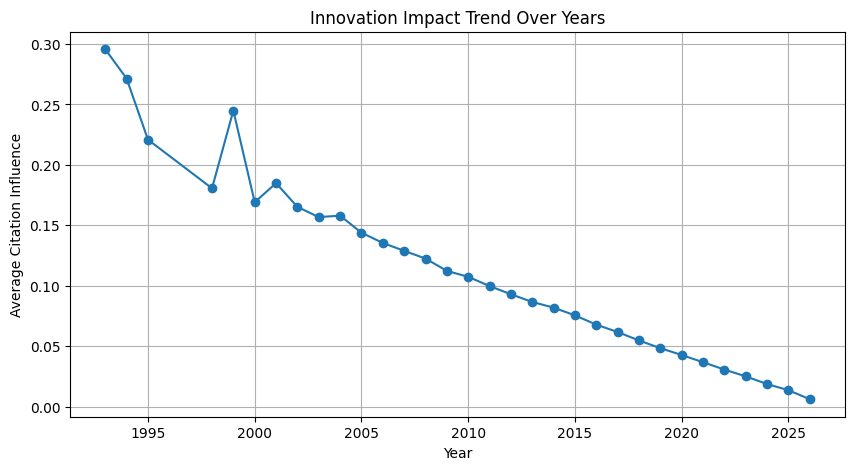

In [28]:
#Step 12: Filing Year vs Citation Impact

year_citation = (
    df.groupby("filing_year")
    ["citation_influence_score"]
    .mean()
    .reset_index()
)


plt.figure(figsize=(10,5))


plt.plot(
    year_citation["filing_year"],
    year_citation["citation_influence_score"],
    marker="o"
)


plt.xlabel("Year")

plt.ylabel(
    "Average Citation Influence"
)


plt.title(
    "Innovation Impact Trend Over Years"
)


plt.grid(True)

plt.show()

In [29]:
#Step 13: Save Results
top_patents.to_csv(
"../results/citation_analysis/citation_influence_ranking.csv",
index=False
)